In [1]:
# 2) Mount Drive (بدري) عشان أي حاجة تتحفظ فورًا
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.7 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
from ultralytics import YOLO
import os
from pathlib import Path
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="J4Y4HKkJK8C7YyXrKD0O")
project = rf.workspace("openglpro").project("stanford_car")
version = project.version(10)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Stanford_Car-10 in yolov8:: 100%|██████████| 60720/60720 [00:12<00:00, 4921.26it/s]


In [5]:
from ultralytics import YOLO
import os

DATA_YAML = "/content/Stanford_Car-10/data.yaml"

In [ ]:
model = YOLO("yolov8n.pt")   # nano = أسرع تدريب

In [ ]:
RUNS_ROOT = "/content/drive/MyDrive/yolo_runs"  # كل الرنز هنا على درايف
RUN_NAME  = "my_train"

In [ ]:
import os

WEIGHTS_DIR = f"{RUNS_ROOT}/detect/{RUN_NAME}/weights"
LAST_PT = f"{WEIGHTS_DIR}/last.pt"
BEST_PT = f"{WEIGHTS_DIR}/best.pt"

print("Weights dir:", WEIGHTS_DIR)
print("Last exists?", os.path.exists(LAST_PT))
print("Best exists?", os.path.exists(BEST_PT))


Weights dir: /content/drive/MyDrive/yolo_runs/detect/my_train/weights
Last exists? True
Best exists? True


In [ ]:
done = 0
start_weights = LAST_PT if os.path.exists(LAST_PT) else "yolov8n.pt"
print("Starting from:", start_weights)

Starting from: yolov8n.pt


In [ ]:
TOTAL_EPOCHS = 30   # زي ما انتي عايزة
CHUNK = 5           # يعني 5 epochs كل مرة (غيريها 1 لو السيشن بيفصل كتير)

IMG_SIZE = 512
BATCH = 16
WORKERS = 2
CACHE = True
OPTIMIZER = "AdamW"
LR0 = 0.001
PATIENCE = 10
DEVICE = 0

done = 0


In [ ]:
!nvidia-smi


Sun Feb 15 15:01:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
while done < TOTAL_EPOCHS:
    this_chunk = min(CHUNK, TOTAL_EPOCHS - done)
    print(f"\n=== Chunk: {done} -> {done + this_chunk} / {TOTAL_EPOCHS} ===")

    start_weights = LAST_PT if os.path.exists(LAST_PT) else start_weights
    model = YOLO(start_weights)

    results = model.train(
        data=DATA_YAML,
        epochs=this_chunk,
        imgsz=IMG_SIZE,
        batch=BATCH,
        workers=WORKERS,
        cache=CACHE,
        optimizer=OPTIMIZER,
        lr0=LR0,
        patience=PATIENCE,
        device=DEVICE,

        project=RUNS_ROOT,
        name=f"detect/{RUN_NAME}",
        exist_ok=True,
        save_period=1
    )


=== Chunk: 0 -> 5 / 30 ===
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Stanford_Car-10/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

KeyboardInterrupt: 

In [6]:
import os

BEST = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt"
LAST = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/last.pt"

print("best exists:", os.path.exists(BEST), "| size:", os.path.getsize(BEST) if os.path.exists(BEST) else None)
print("last exists:", os.path.exists(LAST), "| size:", os.path.getsize(LAST) if os.path.exists(LAST) else None)


best exists: True | size: 18449507
last exists: True | size: 18449507


In [7]:
from ultralytics import YOLO

m = YOLO("/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt")
print("Loaded best.pt ✅")


Loaded best.pt ✅


In [8]:
!cp -f "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt" "/content/drive/MyDrive/best.pt"


In [9]:
done += this_chunk
print("✅ last.pt:", os.path.exists(LAST_PT), "| best.pt:", os.path.exists(BEST_PT))

NameError: name 'done' is not defined

In [10]:
import yaml
from pathlib import Path

DATA_YAML = "/content/Stanford_Car-10/data.yaml"

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

base = Path(DATA_YAML).parent

def to_abs(p):
    if p is None:
        return None
    p = str(p)
    return str((base / p).resolve()) if not p.startswith("/") else p

print("train:", to_abs(data.get("train")))
print("val  :", to_abs(data.get("val")))
print("test :", to_abs(data.get("test")))
print("names:", data.get("names"))


train: /content/train/images
val  : /content/valid/images
test : /content/test/images
names: ['motorbike', 'vehicle']


In [11]:
from ultralytics import YOLO
import os

BEST_PT = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt"
assert os.path.exists(BEST_PT)

model = YOLO(BEST_PT)
print("✅ Model loaded")


✅ Model loaded


In [15]:
import glob
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt")

test_imgs = sorted(glob.glob("/content/Stanford_Car-10/test/images/*"))
start, end = 0, 50   # ✨ عدّلي الرينج
subset = test_imgs[start:end]

res = model.predict(
    source=subset,            # ✅ list
    imgsz=512,
    conf=0.25,
    iou=0.7,
    save=True,
    save_txt=True,
    project="/content/drive/MyDrive/yolo_preds",
    name=f"test_{start}_{end}",
    exist_ok=True,
    device="cpu"
)

print("✅ Saved to:", res[0].save_dir)





0: 512x512 1 vehicle, 228.9ms
1: 512x512 1 vehicle, 228.9ms
2: 512x512 1 vehicle, 228.9ms
3: 512x512 2 vehicles, 228.9ms
4: 512x512 1 vehicle, 228.9ms
5: 512x512 1 vehicle, 228.9ms
6: 512x512 1 vehicle, 228.9ms
7: 512x512 1 vehicle, 228.9ms
8: 512x512 1 vehicle, 228.9ms
9: 512x512 1 vehicle, 228.9ms
10: 512x512 1 vehicle, 228.9ms
11: 512x512 1 vehicle, 228.9ms
12: 512x512 1 vehicle, 228.9ms
13: 512x512 1 vehicle, 228.9ms
14: 512x512 1 vehicle, 228.9ms
15: 512x512 1 vehicle, 228.9ms
16: 512x512 1 vehicle, 228.9ms
17: 512x512 1 vehicle, 228.9ms
18: 512x512 1 vehicle, 228.9ms
19: 512x512 1 vehicle, 228.9ms
20: 512x512 1 vehicle, 228.9ms
21: 512x512 1 vehicle, 228.9ms
22: 512x512 1 vehicle, 228.9ms
23: 512x512 1 vehicle, 228.9ms
24: 512x512 1 vehicle, 228.9ms
25: 512x512 1 vehicle, 228.9ms
26: 512x512 1 vehicle, 228.9ms
27: 512x512 1 vehicle, 228.9ms
28: 512x512 1 vehicle, 228.9ms
29: 512x512 1 vehicle, 228.9ms
30: 512x512 1 vehicle, 228.9ms
31: 512x512 1 vehicle, 228.9ms
32: 512x512 1 ve

Predicted images: 50


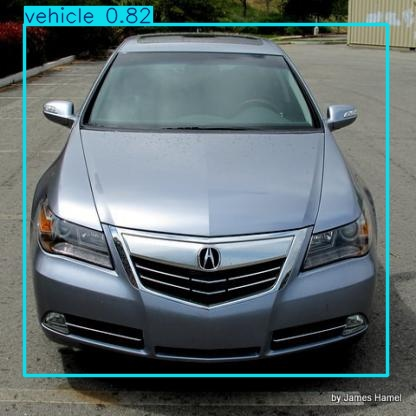

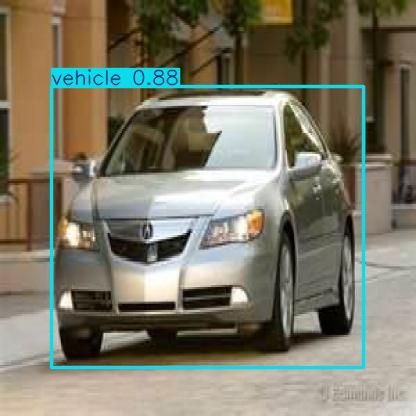

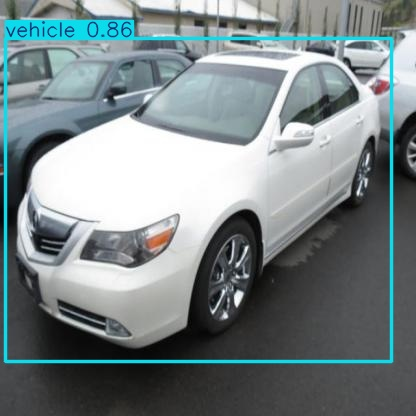

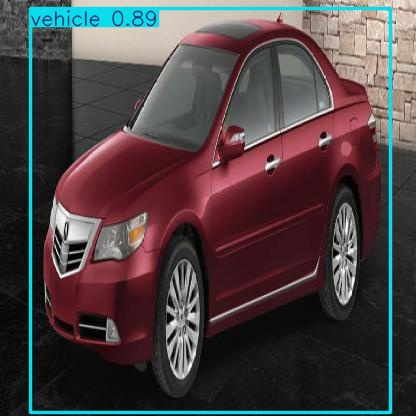

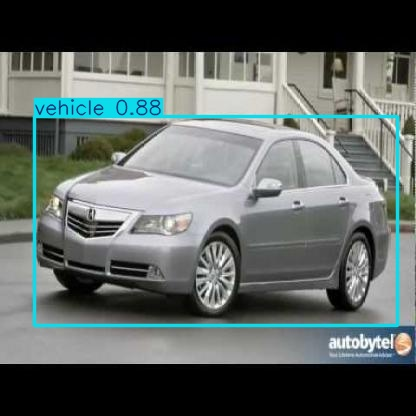

In [16]:
import glob
from IPython.display import Image, display

pred_dir = "/content/drive/MyDrive/yolo_preds/test_0_50"
pred_imgs = sorted(glob.glob(pred_dir + "/*.jpg")) + sorted(glob.glob(pred_dir + "/*.png"))

print("Predicted images:", len(pred_imgs))

for p in pred_imgs[5:10]:
    display(Image(filename=p))


Predicted images: 1266


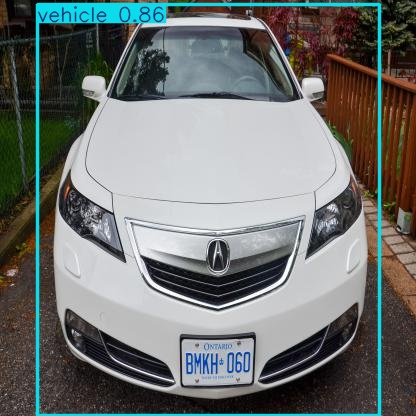

In [17]:
import glob
from IPython.display import Image, display

pred_imgs = sorted(glob.glob("/content/drive/MyDrive/yolo_preds/test_only/*.jpg")) + \
            sorted(glob.glob("/content/drive/MyDrive/yolo_preds/test_only/*.png"))

print("Predicted images:", len(pred_imgs))
display(Image(filename=pred_imgs[12]))


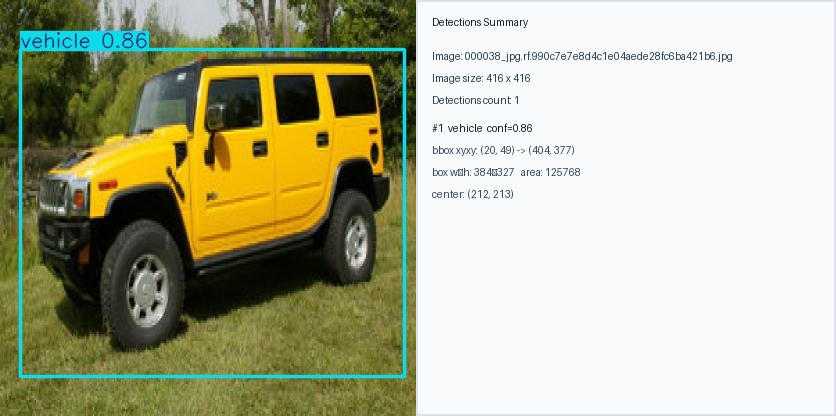

In [19]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/yolo_preds/one_full_info/with_full_info.png"))


In [21]:
from google.colab import files
uploaded = files.upload()   # ارفعي الصورة
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)


Saving 301364176daa715c1629dd706e944828.png to 301364176daa715c1629dd706e944828.png
Uploaded: 301364176daa715c1629dd706e944828.png


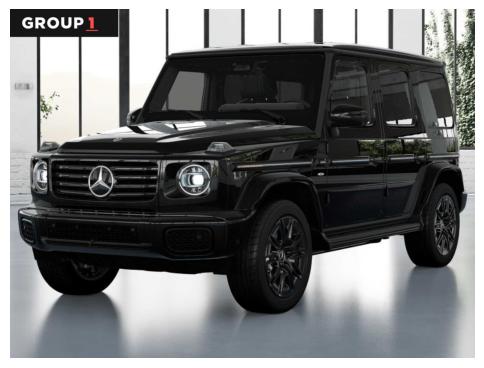

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()


In [23]:
from PIL import Image

img = Image.open(img_path)
print("Size:", img.size)     # (W,H)
print("Mode:", img.mode)     # RGB / RGBA ...



Size: (1600, 1200)
Mode: RGB


In [24]:
import os
print("Exists:", os.path.exists(img_path))
print("Path:", img_path)


Exists: True
Path: 301364176daa715c1629dd706e944828.png



image 1/1 /content/301364176daa715c1629dd706e944828.png: 384x512 1 vehicle, 237.6ms
Speed: 3.2ms preprocess, 237.6ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 512)
Results saved to /content/drive/MyDrive/yolo_preds/external_one
✅ Results folder: /content/drive/MyDrive/yolo_preds/external_one
✅ YOLO annotated: /content/drive/MyDrive/yolo_preds/external_one/301364176daa715c1629dd706e944828.jpg
✅ Saved final: /content/drive/MyDrive/yolo_preds/external_one/with_full_info.png


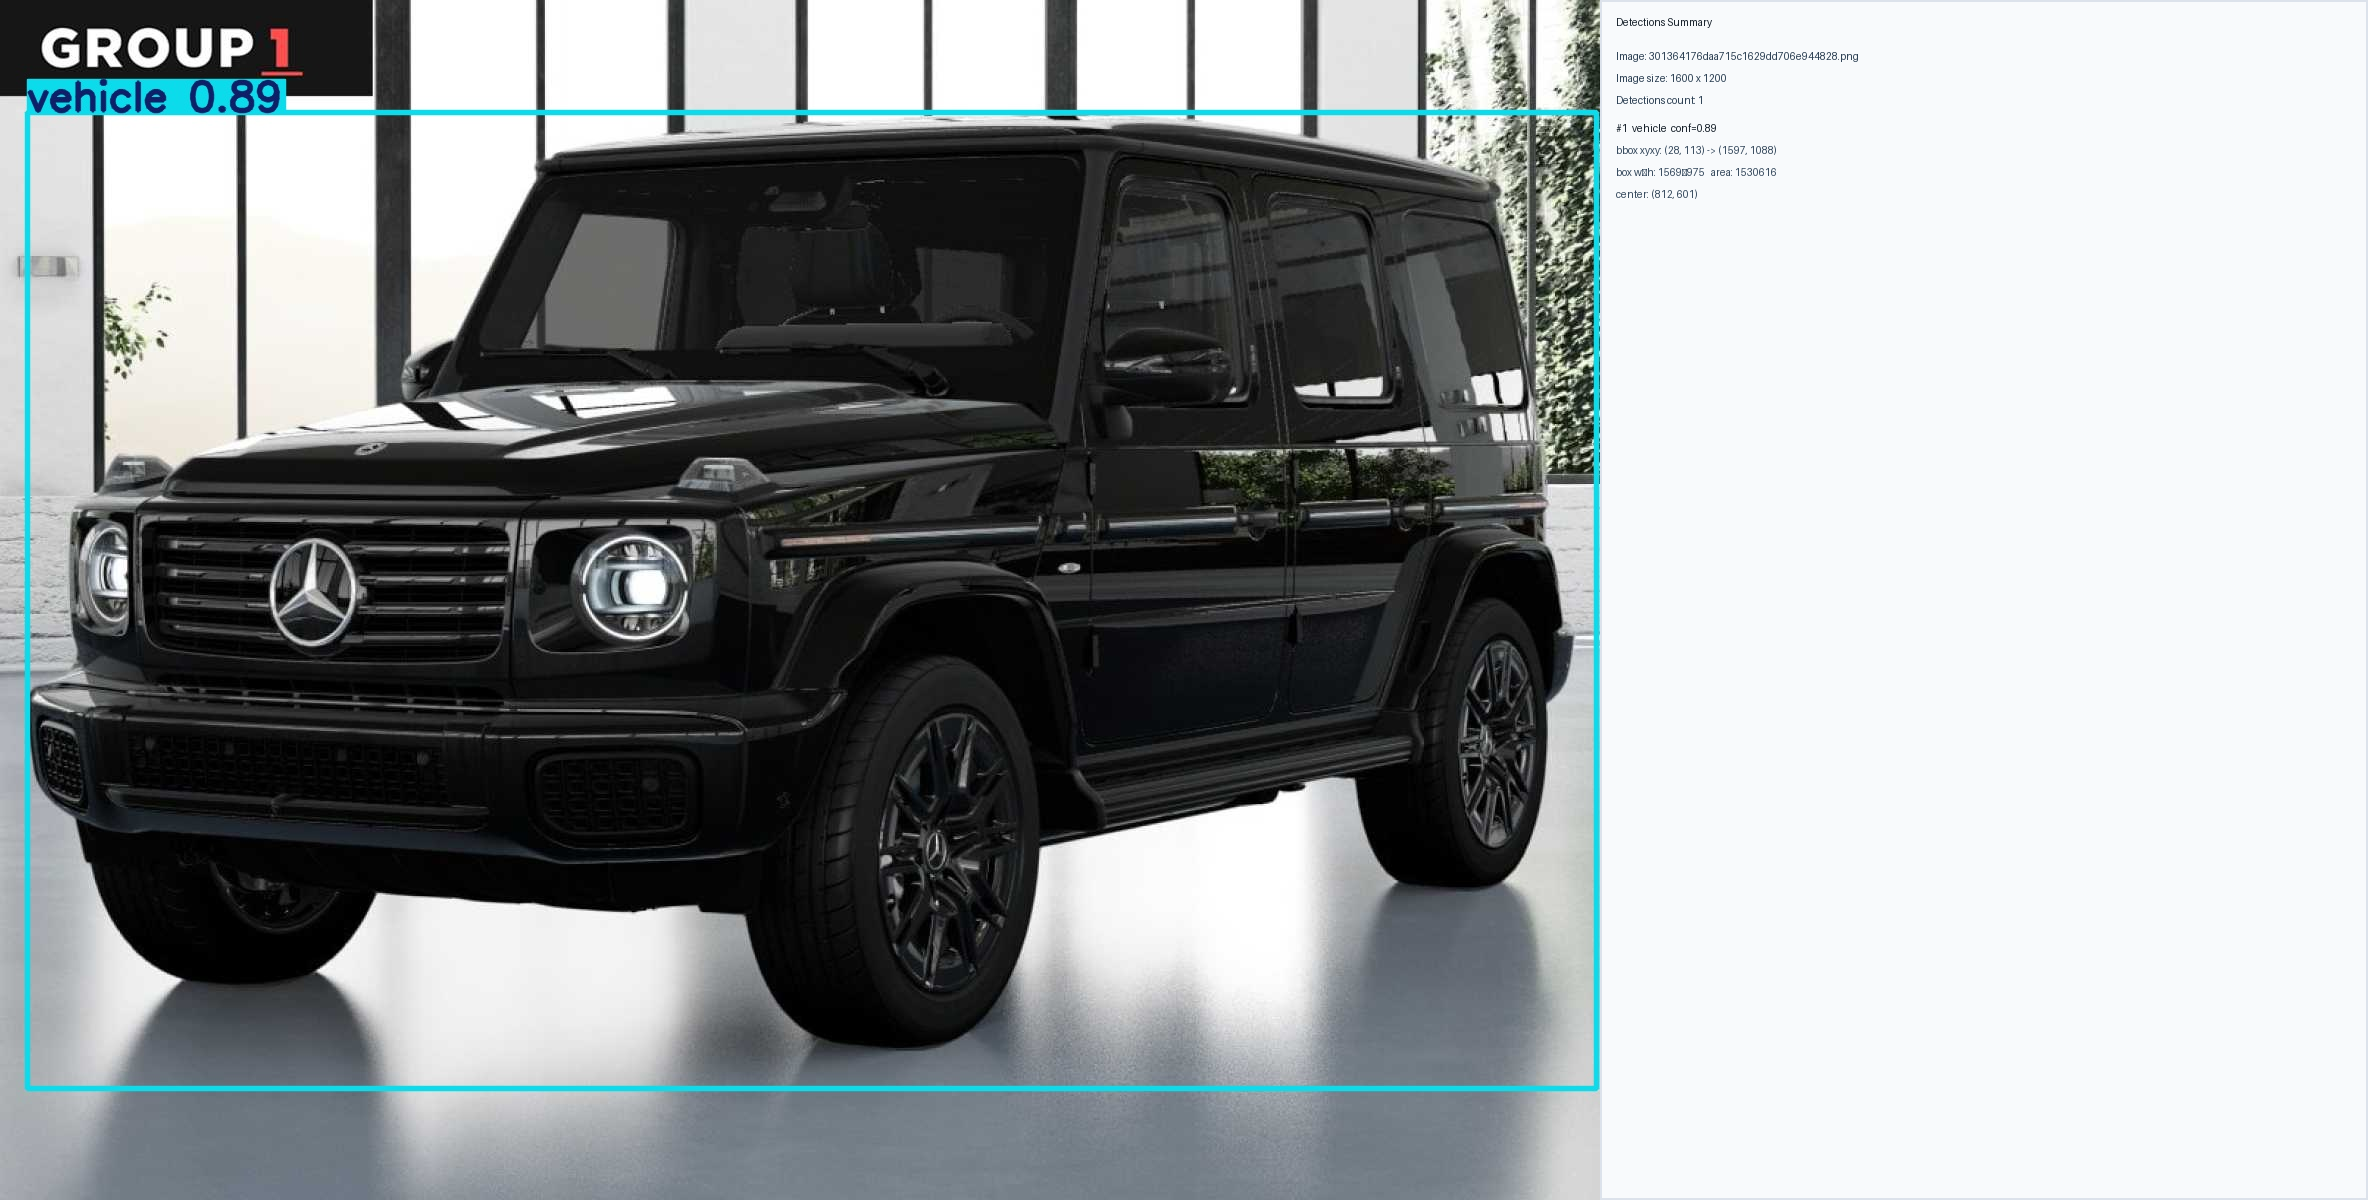

In [30]:
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import os, glob

# 1) Load trained model
BEST_PT = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt"
model = YOLO(BEST_PT)

# 2) Predict on your uploaded external image (img_path لازم يكون موجود من سيل الرفع)

res = model.predict(
    source=img_path,
    imgsz=512,
    conf=0.25,
    iou=0.7,
    save=True,
    project="/content/drive/MyDrive/yolo_preds",
    name="external_one",
    exist_ok=True,
    device="cpu"
)

r = res[0]
save_dir = r.save_dir
print("✅ Results folder:", save_dir)

# 3) Find YOLO annotated saved image
pred_imgs = sorted(glob.glob(save_dir + "/*.jpg")) + sorted(glob.glob(save_dir + "/*.png"))
yolo_img_path = pred_imgs[0]
print("✅ YOLO annotated:", yolo_img_path)

# 4) Extract detections
names = r.names
boxes = r.boxes

detections = []
if boxes is not None and len(boxes) > 0:
    xyxy = boxes.xyxy.cpu().tolist()
    confs = boxes.conf.cpu().tolist()
    clss  = boxes.cls.cpu().tolist()

    for i, (b, c, k) in enumerate(zip(xyxy, confs, clss), start=1):
        x1,y1,x2,y2 = [float(v) for v in b]
        w = x2 - x1
        h = y2 - y1
        area = w*h
        cx = x1 + w/2
        cy = y1 + h/2

        detections.append({
            "idx": i,
            "class": names[int(k)],   # vehicle / motorbike
            "conf": c,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "w": w, "h": h, "area": area,
            "cx": cx, "cy": cy
        })

detections.sort(key=lambda d: d["conf"], reverse=True)

# 5) Make image with info panel
img = Image.open(yolo_img_path).convert("RGBA")
W, H = img.size
panel_w = max(420, int(W * 0.48))

out = Image.new("RGBA", (W + panel_w, H), (255, 255, 255, 255))
out.paste(img, (0, 0))
draw = ImageDraw.Draw(out)

font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
bold_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
font = ImageFont.truetype(font_path, 18) if os.path.exists(font_path) else ImageFont.load_default()
bold = ImageFont.truetype(bold_path, 22) if os.path.exists(bold_path) else font

px0 = W
draw.rectangle([px0, 0, W + panel_w - 1, H - 1],
               fill=(248, 250, 252, 255),
               outline=(220, 226, 235, 255),
               width=2)

x = px0 + 16
y = 16

draw.text((x, y), "Detections Summary", font=bold, fill=(20, 30, 40, 255))
y += 34
draw.text((x, y), f"Image: {os.path.basename(img_path)}", font=font, fill=(40, 60, 80, 255)); y += 22
draw.text((x, y), f"Image size: {W} x {H}", font=font, fill=(40, 60, 80, 255)); y += 22
draw.text((x, y), f"Detections count: {len(detections)}", font=font, fill=(40, 60, 80, 255)); y += 10

if len(detections) == 0:
    y += 18
    draw.text((x, y), "No detections.", font=bold, fill=(160, 60, 60, 255))
else:
    y += 18
    for d in detections:
        block = (
            f"#{d['idx']}  {d['class']}  conf={d['conf']:.2f}\n"
            f"bbox xyxy: ({d['x1']:.0f}, {d['y1']:.0f}) -> ({d['x2']:.0f}, {d['y2']:.0f})\n"
            f"box w×h: {d['w']:.0f}×{d['h']:.0f}   area: {d['area']:.0f}\n"
            f"center: ({d['cx']:.0f}, {d['cy']:.0f})"
        )
        for ln_i, ln in enumerate(block.split("\n")):
            draw.text((x, y), ln, font=(bold if ln_i == 0 else font),
                      fill=(15, 25, 35, 255) if ln_i == 0 else (50, 70, 90, 255))
            y += 22
        y += 10
        if y > H - 60:
            draw.text((x, H - 40), "...more not shown", font=font, fill=(90, 105, 120, 255))
            break

out_path = "/content/drive/MyDrive/yolo_preds/external_one/with_full_info.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
out.convert("RGB").save(out_path, quality=95)
print("✅ Saved final:", out_path)

# 6) Display
from IPython.display import Image as IPImage, display
display(IPImage(out_path))


In [55]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("uploaded:", img_path)

Saving Screenshot 2026-02-16 015046.png to Screenshot 2026-02-16 015046.png
uploaded: Screenshot 2026-02-16 015046.png


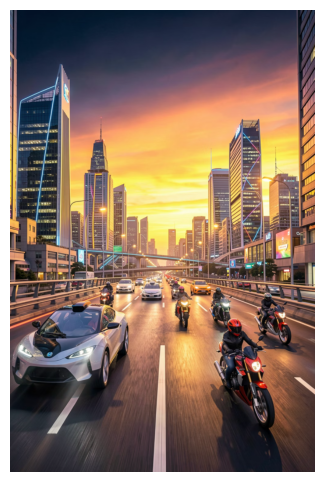

In [56]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [57]:
from PIL import Image

img = Image.open(img_path)
print("Size:", img.size)     # (W,H)
print("Mode:", img.mode)     # RGB / RGBA ...

Size: (524, 794)
Mode: RGBA


In [58]:
!pip -q install ultralytics

✅ Saved annotated: /content/drive/MyDrive/yolo_preds/external_one/annotated_Screenshot 2026-02-16 015046.png
✅ Detections: 4


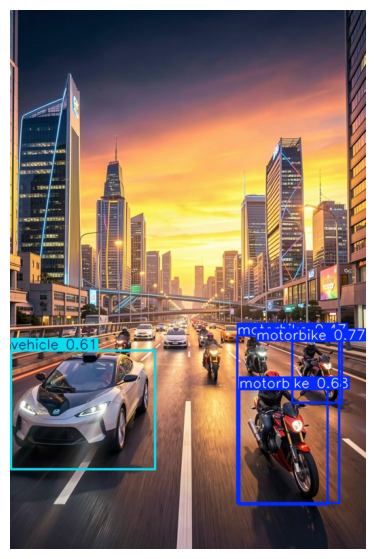

In [59]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt
import cv2

# ✅ 0) image path (uploaded)
img_path = "/content/Screenshot 2026-02-16 015046.png"

# ✅ 1) convert JFIF -> JPG (حل مشاكل القراءة/التنسيق)
img = Image.open(img_path).convert("RGB")
img_jpg = "/content/temp_input.jpg"
img.save(img_jpg, quality=95)

# ✅ 2) paths
BEST_PT = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt"
out_dir = "/content/drive/MyDrive/yolo_preds/external_one"
os.makedirs(out_dir, exist_ok=True)

# ✅ 3) load model
model = YOLO(BEST_PT)

# ✅ 4) predict
res = model.predict(
    source=img_jpg,      # 👈 استخدمي الملف المحوّل
    imgsz=640,
    conf=0.25,           # لو 0 detections خليها 0.10
    iou=0.7,
    device="cpu",
    verbose=False
)

r = res[0]

# ✅ 5) annotate + save (اسم حسب الصورة)
annot_bgr = r.plot()
base = os.path.splitext(os.path.basename(img_path))[0]
annot_path = os.path.join(out_dir, f"annotated_{base}.png")
cv2.imwrite(annot_path, annot_bgr)

print("✅ Saved annotated:", annot_path)
print("✅ Detections:", 0 if r.boxes is None else len(r.boxes))

# ✅ 6) display
annot_rgb = cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(7,7))
plt.imshow(annot_rgb)
plt.axis("off")
plt.show()


In [39]:
from google.colab import files
uploaded = files.upload()   # ارفعي الصورة
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving OIP (1).jfif to OIP (1) (1).jfif
Uploaded: OIP (1) (1).jfif


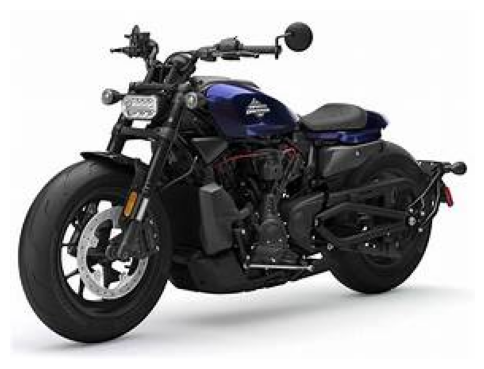

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [41]:
from PIL import Image

img = Image.open(img_path)
print("Size:", img.size)     # (W,H)
print("Mode:", img.mode)     # RGB / RGBA ...



Size: (293, 220)
Mode: RGB


In [42]:
!pip -q install ultralytics


✅ Saved annotated: /content/drive/MyDrive/yolo_preds/external_one/annotated_OIP (1) (1).png
✅ Detections: 2


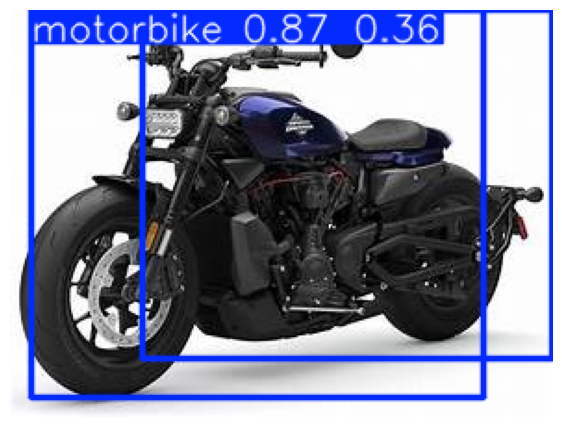

In [45]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt
import cv2

# ✅ 0) image path (uploaded)
img_path = "OIP (1) (1).jfif"

# ✅ 1) convert JFIF -> JPG (حل مشاكل القراءة/التنسيق)
img = Image.open(img_path).convert("RGB")
img_jpg = "/content/temp_input.jpg"
img.save(img_jpg, quality=95)

# ✅ 2) paths
BEST_PT = "/content/drive/MyDrive/yolo_runs/detect/my_train/weights/best.pt"
out_dir = "/content/drive/MyDrive/yolo_preds/external_one"
os.makedirs(out_dir, exist_ok=True)

# ✅ 3) load model
model = YOLO(BEST_PT)

# ✅ 4) predict
res = model.predict(
    source=img_jpg,      # 👈 استخدمي الملف المحوّل
    imgsz=640,
    conf=0.25,           # لو 0 detections خليها 0.10
    iou=0.7,
    device="cpu",
    verbose=False
)

r = res[0]

# ✅ 5) annotate + save (اسم حسب الصورة)
annot_bgr = r.plot()
base = os.path.splitext(os.path.basename(img_path))[0]
annot_path = os.path.join(out_dir, f"annotated_{base}.png")
cv2.imwrite(annot_path, annot_bgr)

print("✅ Saved annotated:", annot_path)
print("✅ Detections:", 0 if r.boxes is None else len(r.boxes))

# ✅ 6) display
annot_rgb = cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(7,7))
plt.imshow(annot_rgb)
plt.axis("off")
plt.show()


In [54]:
r = res[0]
print("names:", r.names)
if r.boxes is not None:
    print("cls:", r.boxes.cls.cpu().tolist())
    print("conf:", [float(x) for x in r.boxes.conf.cpu().tolist()])


names: {0: 'motorbike', 1: 'vehicle'}
cls: [0.0, 0.0, 0.0, 1.0]
conf: [0.7301598787307739, 0.639863133430481, 0.44211187958717346, 0.31607696413993835]
